In [1]:
#Importamos librerías requeridas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Carga desde un archivo .csv sin indice
data = pd.read_csv('Leads_Reales_Limpia.csv')
data

,Año,Mes,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad
0,2024,Febrero,543,108,33,0,1,389,1,12,3.1,72
1,2024,Marzo,178,37,13,0,0,128,1,7,5.5,72
2,2024,Abril,416,79,46,3,0,288,1,8,2.8,69
3,2024,Mayo,422,33,100,17,0,274,5,13,4.7,65
4,2024,Junio,967,140,173,31,3,620,17,6,1.0,64
5,2024,Julio,954,112,251,12,9,570,5,21,3.7,60
6,2024,Agosto,1409,504,324,17,18,546,22,17,3.1,39
7,2024,Septiembre,1315,431,314,14,26,530,42,17,3.2,40
8,2024,Octubre,1973,514,606,18,13,822,72,23,2.8,42
9,2024,Noviembre,1562,153,321,44,4,1040,79,22,2.1,67


In [3]:
# Convertir los meses a valores numéricos
meses = {
    'Enero': 1,
    'Febrero': 2,
    'Marzo': 3,
    'Abril': 4,
    'Mayo': 5,
    'Junio': 6,
    'Julio': 7,
    'Agosto': 8,
    'Septiembre': 9,
    'Octubre': 10,
    'Noviembre': 11,
    'Diciembre': 12
}

data['Mes'] = data['Mes'].map(meses)

data

,Año,Mes,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad
0,2024,2,543,108,33,0,1,389,1,12,3.1,72
1,2024,3,178,37,13,0,0,128,1,7,5.5,72
2,2024,4,416,79,46,3,0,288,1,8,2.8,69
3,2024,5,422,33,100,17,0,274,5,13,4.7,65
4,2024,6,967,140,173,31,3,620,17,6,1.0,64
5,2024,7,954,112,251,12,9,570,5,21,3.7,60
6,2024,8,1409,504,324,17,18,546,22,17,3.1,39
7,2024,9,1315,431,314,14,26,530,42,17,3.2,40
8,2024,10,1973,514,606,18,13,822,72,23,2.8,42
9,2024,11,1562,153,321,44,4,1040,79,22,2.1,67


<Axes: xlabel='Efectivos', ylabel='Ventas'>

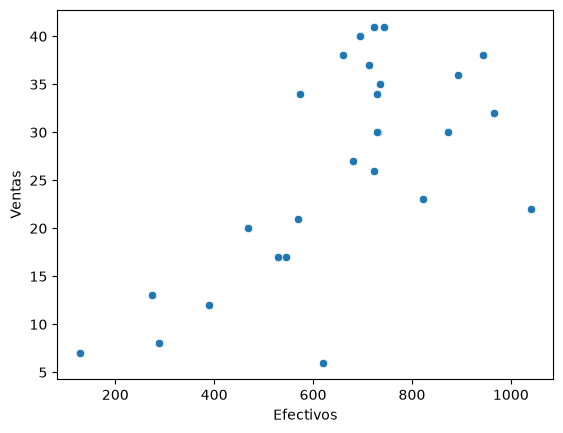

In [4]:
# Imprimimos el scatter plot entre la variable dependiente (Ventas)
# e independiente (Efectivos) para observar su dispersión

sns.scatterplot(x='Efectivos', y='Ventas', data=data)

In [5]:
# Declaramos las variables dependiente e independiente
# para la regresión lineal

Vars_Indep = data[['Efectivos']]
Var_Dep = data['Ventas']

In [6]:
# Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.03]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Efectivos']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.353
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [7]:
# Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Efectivos'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.03425144]),
 'rank_': np.int64(1),
 'singular_': array([1101.17910831]),
 'intercept_': np.float64(4.3534404597081355)}

In [8]:
print("Intercepto:", model.intercept_)
print("Coeficiente:", model.coef_[0])

Intercepto: 4.3534404597081355
Coeficiente: 0.03425144271414046


In [9]:
# Evaluamos la eficiencia del modelo mediante
# el coeficiente de determinación R²

model.score(Vars_Indep, Var_Dep)

0.4288771119533772

In [10]:
# Predecimos los valores de Ventas
y_pred = model.predict(X=data[['Efectivos']])

y_pred

array([17.67725168,  8.73762513, 14.21785596, 13.73833576, 25.58933494,
       23.87676281, 23.05472818, 22.5067051 , 32.50812637, 39.97494088,
       37.40608268, 29.11723354, 20.38311565, 29.39124508, 34.22069851,
       24.01376858, 28.1239417 , 34.9399788 , 27.67867295, 26.95939265,
       28.15819315, 29.83651384, 29.3227422 , 28.80897056, 29.35699364,
       36.68680238, 29.15148498, 29.5625023 ])

In [11]:
# Insertamos la columna de predicciones en el DataFrame
data.insert(0, 'Predicciones', y_pred)

data

,Predicciones,Año,Mes,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad
0,17.677252,2024,2,543,108,33,0,1,389,1,12,3.1,72
1,8.737625,2024,3,178,37,13,0,0,128,1,7,5.5,72
2,14.217856,2024,4,416,79,46,3,0,288,1,8,2.8,69
3,13.738336,2024,5,422,33,100,17,0,274,5,13,4.7,65
4,25.589335,2024,6,967,140,173,31,3,620,17,6,1.0,64
5,23.876763,2024,7,954,112,251,12,9,570,5,21,3.7,60
6,23.054728,2024,8,1409,504,324,17,18,546,22,17,3.1,39
7,22.506705,2024,9,1315,431,314,14,26,530,42,17,3.2,40
8,32.508126,2024,10,1973,514,606,18,13,822,72,23,2.8,42
9,39.974941,2024,11,1562,153,321,44,4,1040,79,22,2.1,67


<Axes: xlabel='Efectivos', ylabel='Ventas'>

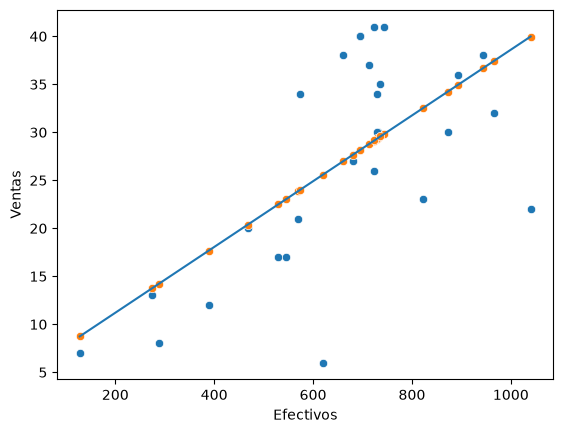

In [12]:
# Visualizamos la gráfica comparativa entre
# las ventas reales y las ventas predichas

sns.scatterplot(x='Efectivos', y='Ventas', data=data)
sns.scatterplot(x='Efectivos', y='Predicciones', data=data)
sns.lineplot(x='Efectivos', y='Predicciones', data=data)

In [13]:
# Coeficiente de Determinación
coef_Deter = model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

0.4288771119533772

In [14]:
# Coeficiente de Correlación
coef_Correl = np.sqrt(coef_Deter)
coef_Correl

np.float64(0.6548870986310367)

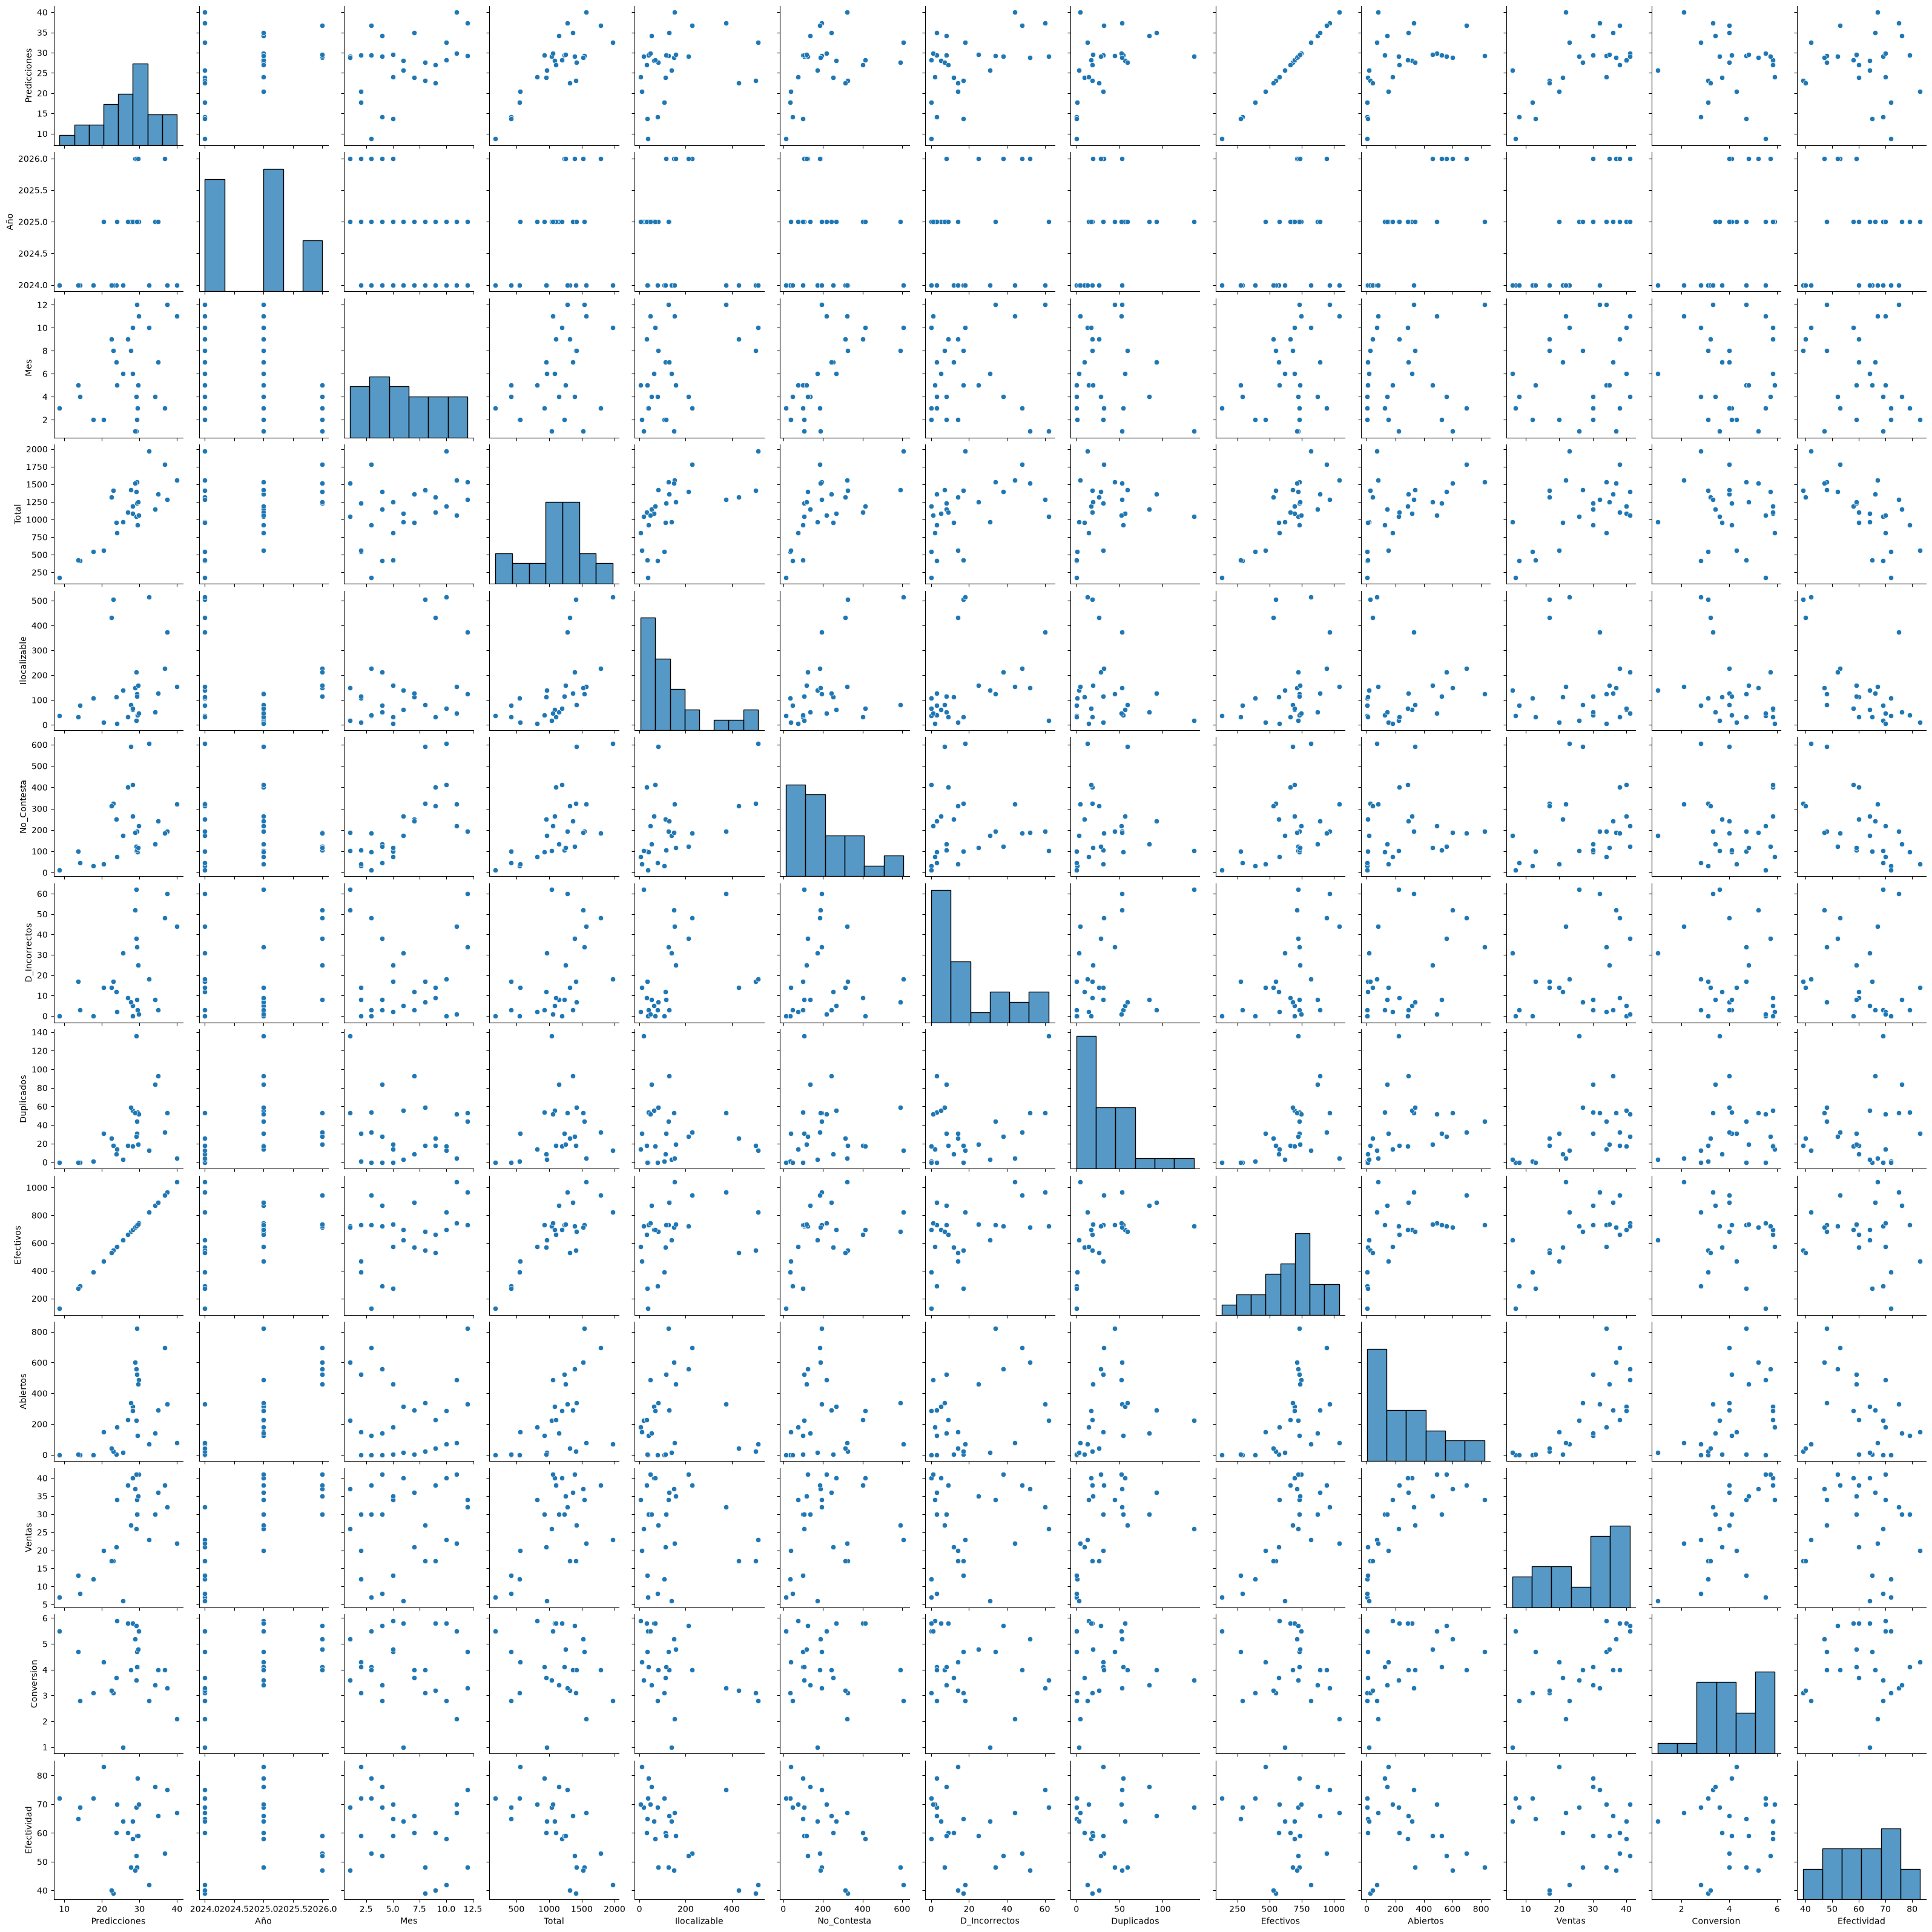

In [15]:
# Graficamos todas las dispersiones entre las variables
sns.pairplot(data)

In [16]:
# Encontramos todas las correlaciones entre las variables
Corr_Factors = data.corr()
Corr_Factors

,Predicciones,Año,Mes,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad
Predicciones,1.000000,0.387510,0.355581,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,-0.137212,-0.115353
Año,0.387510,1.000000,-0.371581,0.344364,-0.266705,-0.131004,0.180612,0.372096,0.387510,0.800323,0.745898,0.536228,-0.105934
Mes,0.355581,-0.371581,1.000000,0.417563,0.393890,0.641403,0.000990,-0.136307,0.355581,0.054022,0.184924,-0.077131,-0.302947
Total,0.812001,0.344364,0.417563,1.000000,0.588110,0.644815,0.453006,0.260949,0.812001,0.528382,0.534564,-0.133595,-0.653776
Ilocalizable,0.245740,-0.266705,0.393890,0.588110,1.000000,0.443577,0.293649,-0.162391,0.245740,-0.047827,-0.106959,-0.413785,-0.645820
No_Contesta,0.383725,-0.131004,0.641403,0.644815,0.443577,1.000000,-0.040028,0.012199,0.383725,0.013522,0.219976,-0.088043,-0.611360
D_Incorrectos,0.468292,0.180612,0.000990,0.453006,0.293649,-0.040028,1.000000,0.287165,0.468292,0.382420,0.143903,-0.247300,-0.177488
Duplicados,0.467451,0.372096,-0.136307,0.260949,-0.162391,0.012199,0.287165,1.000000,0.467451,0.336402,0.451099,0.085728,0.139829
Efectivos,1.000000,0.387510,0.355581,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,-0.137212,-0.115353
Abiertos,0.495192,0.800323,0.054022,0.528382,-0.047827,0.013522,0.382420,0.336402,0.495192,1.000000,0.752551,0.445734,-0.281941


In [17]:
# Encontramos el valor absoluto de todas las correlaciones
Corr_Factors1 = abs(Corr_Factors)
Corr_Factors1

,Predicciones,Año,Mes,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad
Predicciones,1.000000,0.387510,0.355581,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,0.137212,0.115353
Año,0.387510,1.000000,0.371581,0.344364,0.266705,0.131004,0.180612,0.372096,0.387510,0.800323,0.745898,0.536228,0.105934
Mes,0.355581,0.371581,1.000000,0.417563,0.393890,0.641403,0.000990,0.136307,0.355581,0.054022,0.184924,0.077131,0.302947
Total,0.812001,0.344364,0.417563,1.000000,0.588110,0.644815,0.453006,0.260949,0.812001,0.528382,0.534564,0.133595,0.653776
Ilocalizable,0.245740,0.266705,0.393890,0.588110,1.000000,0.443577,0.293649,0.162391,0.245740,0.047827,0.106959,0.413785,0.645820
No_Contesta,0.383725,0.131004,0.641403,0.644815,0.443577,1.000000,0.040028,0.012199,0.383725,0.013522,0.219976,0.088043,0.611360
D_Incorrectos,0.468292,0.180612,0.000990,0.453006,0.293649,0.040028,1.000000,0.287165,0.468292,0.382420,0.143903,0.247300,0.177488
Duplicados,0.467451,0.372096,0.136307,0.260949,0.162391,0.012199,0.287165,1.000000,0.467451,0.336402,0.451099,0.085728,0.139829
Efectivos,1.000000,0.387510,0.355581,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,0.137212,0.115353
Abiertos,0.495192,0.800323,0.054022,0.528382,0.047827,0.013522,0.382420,0.336402,0.495192,1.000000,0.752551,0.445734,0.281941


<Axes: >

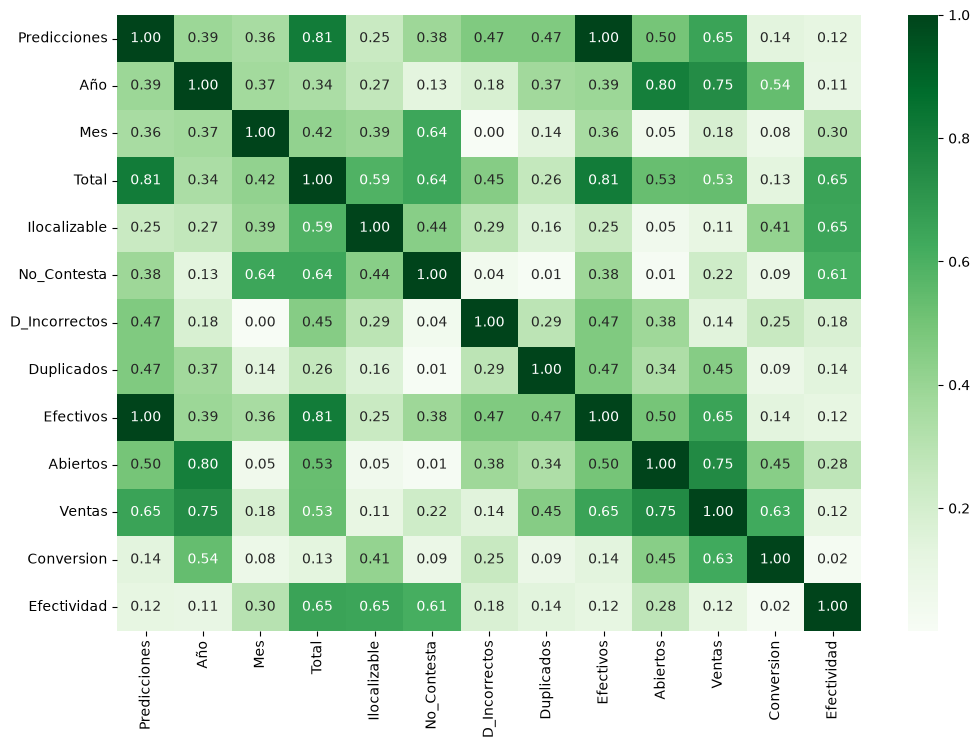

In [20]:
# Graficamos el mapa de calor de los coeficientes de correlación

plt.figure(figsize=(12, 8))

Heat_Map = sns.heatmap(
    Corr_Factors1,
    cmap='Greens',
    annot=True,
    fmt=".2f"
)

Heat_Map

In [19]:
Corr_Factors = data.corr()
Corr_Factors

,Predicciones,Año,Mes,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad
Predicciones,1.000000,0.387510,0.355581,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,-0.137212,-0.115353
Año,0.387510,1.000000,-0.371581,0.344364,-0.266705,-0.131004,0.180612,0.372096,0.387510,0.800323,0.745898,0.536228,-0.105934
Mes,0.355581,-0.371581,1.000000,0.417563,0.393890,0.641403,0.000990,-0.136307,0.355581,0.054022,0.184924,-0.077131,-0.302947
Total,0.812001,0.344364,0.417563,1.000000,0.588110,0.644815,0.453006,0.260949,0.812001,0.528382,0.534564,-0.133595,-0.653776
Ilocalizable,0.245740,-0.266705,0.393890,0.588110,1.000000,0.443577,0.293649,-0.162391,0.245740,-0.047827,-0.106959,-0.413785,-0.645820
No_Contesta,0.383725,-0.131004,0.641403,0.644815,0.443577,1.000000,-0.040028,0.012199,0.383725,0.013522,0.219976,-0.088043,-0.611360
D_Incorrectos,0.468292,0.180612,0.000990,0.453006,0.293649,-0.040028,1.000000,0.287165,0.468292,0.382420,0.143903,-0.247300,-0.177488
Duplicados,0.467451,0.372096,-0.136307,0.260949,-0.162391,0.012199,0.287165,1.000000,0.467451,0.336402,0.451099,0.085728,0.139829
Efectivos,1.000000,0.387510,0.355581,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,-0.137212,-0.115353
Abiertos,0.495192,0.800323,0.054022,0.528382,-0.047827,0.013522,0.382420,0.336402,0.495192,1.000000,0.752551,0.445734,-0.281941
